In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('insurance.csv')

# EDA

In [3]:
df.shape

(1338, 7)

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.isna().count()

age         1338
sex         1338
bmi         1338
children    1338
smoker      1338
region      1338
charges     1338
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
df.columns


Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

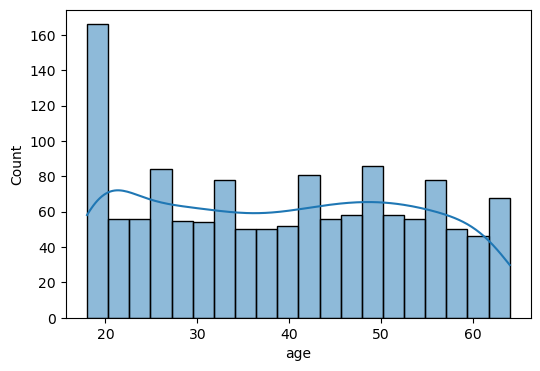

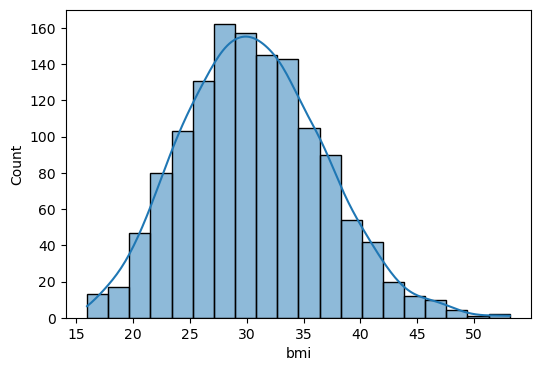

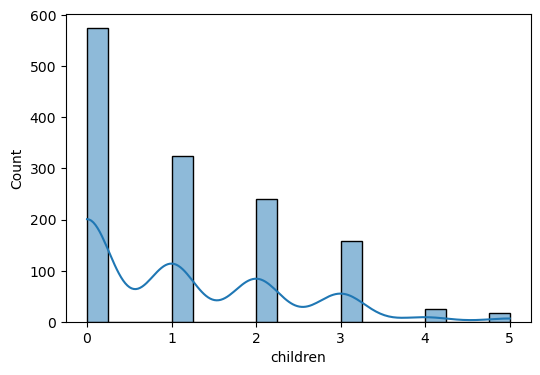

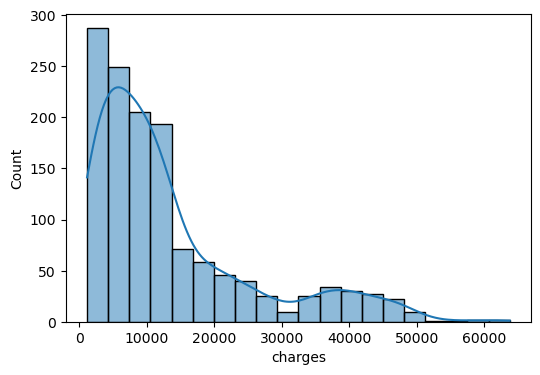

In [9]:
numeric_column = ['age', 'bmi', 'children', 'charges']
for col in numeric_column: 
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde= True, bins=20)

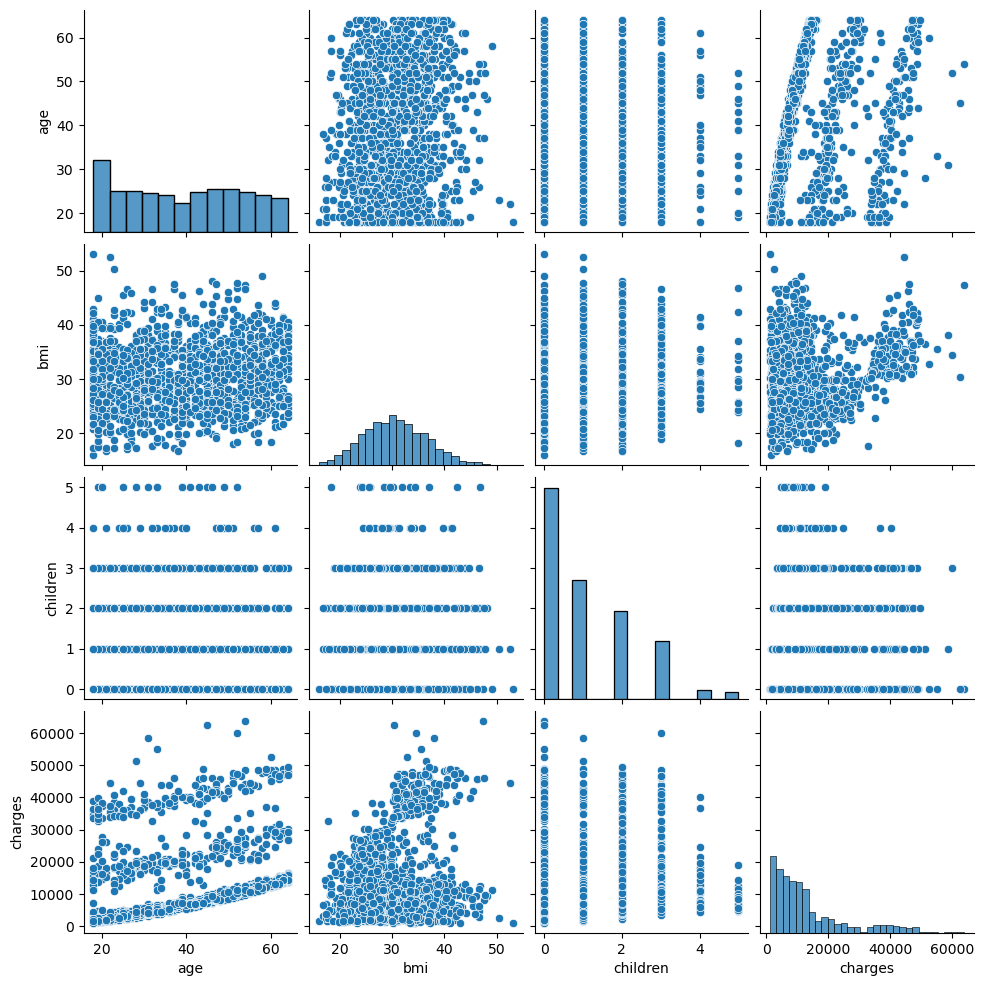

In [10]:
# numeric_column = ['age', 'bmi', 'children', 'charges']
sns.pairplot(df[numeric_column])

In [11]:
# category_column = [ 'sex', 'children', 'smoker', 'region']
# for cols in category_column:
#     plt.figure(figsize=(6,4))
#     sns.countplot(x=df[cols])

<Axes: xlabel='children', ylabel='count'>

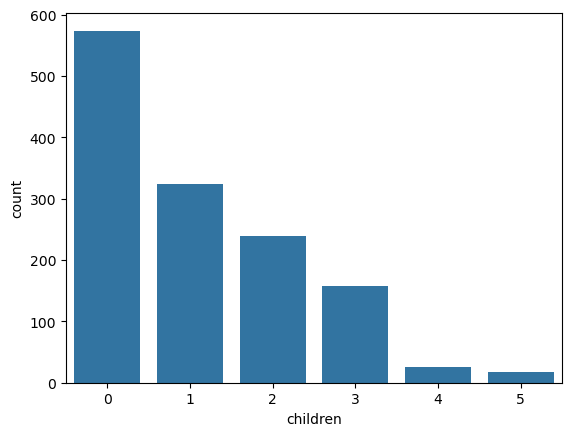

In [12]:
sns.countplot(x=df['children'])

<Axes: xlabel='sex', ylabel='count'>

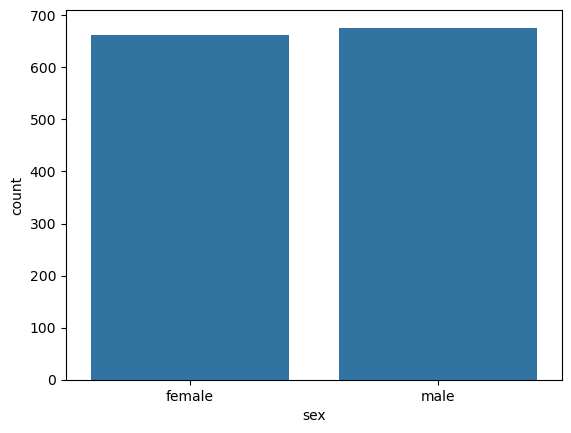

In [13]:
sns.countplot(x=df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

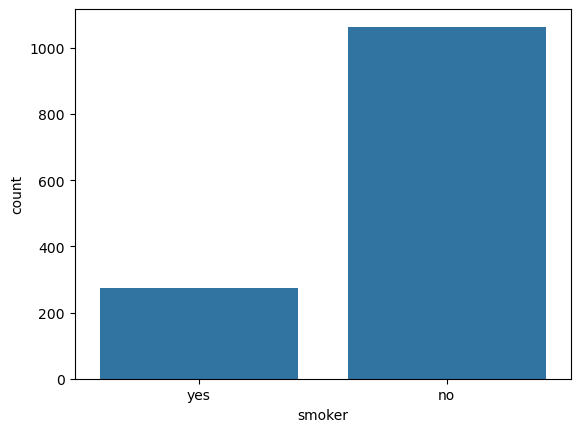

In [14]:
sns.countplot(x= df['smoker'])

<Axes: xlabel='region', ylabel='count'>

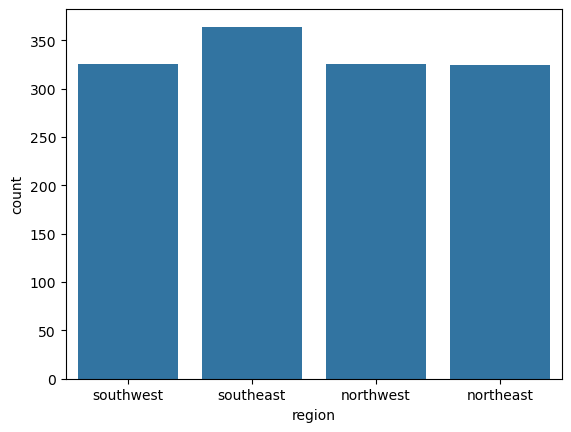

In [15]:
sns.countplot(x= df['region'])

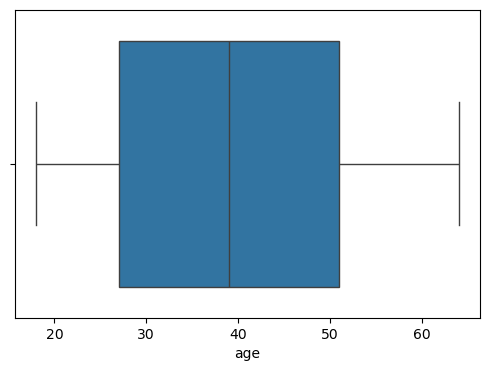

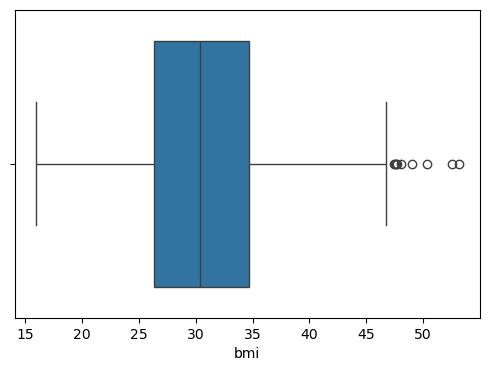

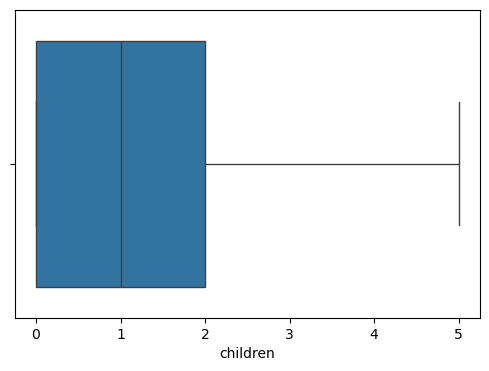

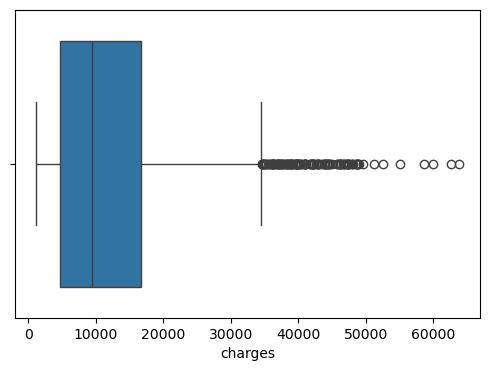

In [16]:
for col in numeric_column: 
    plt.figure(figsize=(6,4))
    sns.boxplot(x = df[col])

<Axes: >

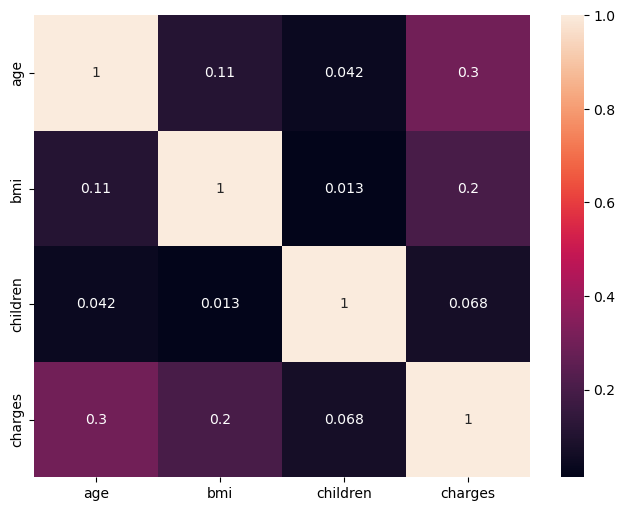

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)

# Data Cleaning And Preprocessing

In [18]:
df_cleaned = df.copy()

In [19]:
df_cleaned.isna().count()

age         1338
sex         1338
bmi         1338
children    1338
smoker      1338
region      1338
charges     1338
dtype: int64

In [20]:
df_cleaned.shape

(1338, 7)

In [21]:
df_cleaned.drop_duplicates(inplace=True)

In [22]:
df_cleaned.shape

(1337, 7)

In [23]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [24]:
df_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

## Encoding converting objects into numeric value 0 or 1

In [25]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [26]:
df_cleaned['sex'] = df_cleaned['sex'].map({'male':0, 'female':1})

In [27]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [28]:
df_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [29]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({'yes':1, 'no':0})

In [30]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


### Remname column 

In [31]:
df_cleaned =  df_cleaned.rename(columns={'sex':'Is_Female', 'smoker':'Is_Smoker'})

In [32]:
df_cleaned.head()

,age,Is_Female,bmi,children,Is_Smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


### OneHot encoding 

In [33]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [34]:
df_cleaned = pd.get_dummies(df_cleaned,columns= ['region'])

In [35]:
df_cleaned.head(2)

,age,Is_Female,bmi,children,Is_Smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.90,0,1,16884.9240,False,False,False,True
1,18,0,33.77,1,0,1725.5523,False,False,True,False


In [36]:
df_cleaned = df_cleaned.astype(int)

In [37]:
df_cleaned.head(2)

,age,Is_Female,bmi,children,Is_Smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0


# Feature Engineering and Extraction 

In [38]:
df_cleaned.head(2)

,age,Is_Female,bmi,children,Is_Smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0


In [39]:
# creating new column bmi category 
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'], bins=[0,18.5,24.9,29.9,float('inf')],
    labels=['Under Weight','Normal Weight','Over Weight','Obesity']
)

In [40]:
df_cleaned.head()

,age,Is_Female,bmi,children,Is_Smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,0,1,Over Weight
1,18,0,33,1,0,1725,0,0,1,0,Obesity
2,28,0,33,3,0,4449,0,0,1,0,Obesity
3,33,0,22,0,0,21984,0,1,0,0,Normal Weight
4,32,0,28,0,0,3866,0,1,0,0,Over Weight


In [41]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['bmi_category'])

In [42]:
df_cleaned = df_cleaned.astype(int)

In [43]:
df_cleaned.head()

,age,Is_Female,bmi,children,Is_Smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Under Weight,bmi_category_Normal Weight,bmi_category_Over Weight,bmi_category_Obesity
0,19,1,27,0,1,16884,0,0,0,1,0,0,1,0
1,18,0,33,1,0,1725,0,0,1,0,0,0,0,1
2,28,0,33,3,0,4449,0,0,1,0,0,0,0,1
3,33,0,22,0,0,21984,0,1,0,0,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0,0,0,1,0


In [44]:
from sklearn.preprocessing import StandardScaler 
cols = ['age','bmi','children']
scaler = StandardScaler()
df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [45]:
df_cleaned.head()

,age,Is_Female,bmi,children,Is_Smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Under Weight,bmi_category_Normal Weight,bmi_category_Over Weight,bmi_category_Obesity
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,0,1,0,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,0,1,0,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,0,1,0,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,1,0,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,1,0,0,0,0,1,0


In [46]:
df_cleaned.columns

Index(['age', 'Is_Female', 'bmi', 'children', 'Is_Smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_Under Weight',
       'bmi_category_Normal Weight', 'bmi_category_Over Weight',
       'bmi_category_Obesity'],
      dtype='object')

### Feature extraction 

In [47]:
from scipy.stats import pearsonr

# person correlation calculation 

# List of features to check against target (charges )

selected_features = ['age', 'Is_Female', 'bmi', 'children', 'Is_Smoker',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_Under Weight',
       'bmi_category_Normal Weight', 'bmi_category_Over Weight',
       'bmi_category_Obesity']

correlations = {
    feature: pearsonr(df_cleaned[feature],df_cleaned['charges'])[0]
    for feature in selected_features
}

correlations_df = pd.DataFrame(list(correlations.items()),columns=['Feature','Pearson Correlation'])
correlations_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
4,Is_Smoker,0.787234
0,age,0.298309
12,bmi_category_Obesity,0.200348
2,bmi,0.196236
7,region_southeast,0.073577
3,children,0.067390
5,region_northeast,0.005946
6,region_northwest,-0.038695
8,region_southwest,-0.043637
9,bmi_category_Under Weight,-0.050599


In [48]:
# Chi Square test

In [49]:
cat_features = [
     'Is_Female', 'Is_Smoker',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_Under Weight',
       'bmi_category_Normal Weight', 'bmi_category_Over Weight',
       'bmi_category_Obesity'
]

In [50]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
Is_Smoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
Is_Female,10.258784,0.01649,Reject Null (Keep Feature)
bmi_category_Obesity,8.515711,0.036473,Reject Null (Keep Feature)
region_northeast,6.438442,0.092122,Accept Null (Drop Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi_category_Over Weight,4.25149,0.235557,Accept Null (Drop Feature)
bmi_category_Normal Weight,3.708088,0.29476,Accept Null (Drop Feature)
bmi_category_Under Weight,3.37403,0.337471,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


In [51]:
final_df = df_cleaned[['age', 'Is_Female', 'bmi', 'children', 'Is_Smoker', 'charges','region_southeast','bmi_category_Obesity']]

In [52]:
final_df

,age,Is_Female,bmi,children,Is_Smoker,charges,region_southeast,bmi_category_Obesity
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1,1
2,-0.799350,0,0.462463,1.580143,0,4449,1,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,1,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0


# spliting the data and training and testing

In [53]:
from sklearn.model_selection import train_test_split

In [58]:
X = final_df.drop('charges', axis=1)
y = final_df['charges']

In [ ]:
# train_test_split()

# Training and Creating model

In [59]:
 X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [60]:
from sklearn.linear_model import LinearRegression

In [61]:
model = LinearRegression()
model.fit(X_train , y_train)

LinearRegression()

In [62]:
y_pred = model.predict(X_test)

In [68]:
# y_pred

In [67]:
# y_test

In [71]:
from sklearn.metrics import r2_score
# R square 
r2 = r2_score(y_test,y_pred)
r2

0.8040712413347119

In [74]:
# adjusted R square 

n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1- ((1-r2) * (n-1) / (n-p-1))
adjusted_r2

0.7987962362937233